# Proyecto: conveniencia de compra en Uruguay

Proyecto final por Georgina Sicco - Grupo F

Curso: Phyton - UCU
Profesor: Hector Chocobar

## Índice:

1. Definición del problema
2. Recopilación de datos
3. Análisis Descriptivo
4. Limpieza de datos
5. Análisis de variables (univariante, multivariante)
6. Ingeniería de características (Duplicados, Faltantes, Nuevas características)
7. Split
8. Scaling & Encoding
9. Selección de características

**Seguiremos la adopción de estos pasos que son los vistos en el curso.**

# **PASO 1: Definición del problema:**

Los consumidores finales cuentan con información imperfecta sobre las tendencias del mercado, las brechas de precios entre los proveedores (en este caso de las cadenas de supermercados y farmacias del Uruguay) y las fclutuaciones en los precios de los productos que consumen, por lo que es imperante resolver este problema de información imperfecta que afecta las finanzas de los consumidores. El objetivo del trabajo es brindar información clara y actualizada para la toma de decisiones del comprador uruguayo que optimice su caapcidad de ahorro y le permita realziar compras más eficientes.

In [123]:
# Importamos librerias necesarias:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.methods import describe
from prompt_toolkit.layout import dimension
from pathlib import Path
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression


# **PASO 2: Recopilación de datos**

Datos extraidos de precios.uy

In [124]:
ruta = r"C:\Users\Georgi Sicco\OneDrive\Escritorio\DIPLOMA\PHYTON\Proyevcto\data\raw\p4ds_cadenas_unificadas_2025.csv"
df = pd.read_csv(ruta)

In [125]:
df.head()

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


In [126]:
# Adjudico nuevo nombre
datos_supermercado = pd.read_csv(ruta)

# **PASO 3: Análisis Descriptivo**

El análisis descriptivo de nuestro dataframe nos permite conocer a qué nos enfrentamos con nuestra base de datos, su tamaño y dimensiones, el formato de las columnas, el tipo de dato y si tenemos valores no nulos. Para ello, describimos a continuación nuestro df.


In [127]:
# Dimensiones
print("Dimensiones de la tabla (Filas, Columnas):")
print(datos_supermercado.shape)
print("-"* 50)

Dimensiones de la tabla (Filas, Columnas):
(26834, 5)
--------------------------------------------------


In [128]:
# Info sobre tipos de datos y valores
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


,count,unique,top,freq
Periodo,26834,12,Dic25,2333
Grupo,26671,10,Alimentos y bebidas,13261
Producto,26812,427,"Jabón de tocador Dove Blanco, 90 grs.",209
Super,24237,17,Red Expres,2260
Precio,26401,2234,"75,00",334


In [129]:
df. duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
26829    False
26830    False
26831    False
26832    False
26833    False
Length: 26834, dtype: bool

In [130]:
# Contar si hay filas completamente duplicadas
total_duplicados = df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {total_duplicados}")

Cantidad de filas duplicadas: 1625


In [131]:
df_duplicados = df[df.duplicated(keep=False)]

print("Muestra de filas duplicadas:")
display(df_duplicados.head(10))

Muestra de filas duplicadas:


,Periodo,Grupo,Producto,Super,Precio
34,Abr25,Alimentos y bebidas,Aceite de girasol Óptimo Envase 900 cc,Ta - Ta,"99,00"
44,Abr25,Alimentos y bebidas,Aceite de maíz Delicia Envase 900 cc,Red Market,"105,00"
54,Abr25,Alimentos y bebidas,Aceite de maíz Río de la Plata Envase 900 cc,Red Market,"139,50"
119,Abr25,Alimentos y bebidas,"Agua de mesa sin gas Matutina 2,5 lts",Red Market,"59,00"
133,Abr25,Alimentos y bebidas,"Agua de mesa sin gas Salus 2,25 lts",Tienda Inglesa,"79,00"
139,Abr25,Alimentos y bebidas,"Agua de mesa sin gas Vitale 2,5 lts",Red Expres,"72,00"
194,Abr25,Alimentos y bebidas,Arroz blanco Blue Patna Bolsa 1 kg.,Red Expres,"72,00"
208,Abr25,Alimentos y bebidas,Arroz blanco Saman Blanco Bolsa 1 kg.,Devoto Express,"87,00"
210,Abr25,Alimentos y bebidas,Arroz blanco Saman Blanco Bolsa 1 kg.,El Clon,"69,00"
247,Abr25,Alimentos y bebidas,Azúcar blanco Azucarlito Paquete 1 kg.,Ta - Ta,"55,00"


#### _Observaciones:_

- Las dimensiones de la tabla se componen por 5 columnas y 26834 filas de las cuales 1625 se encuentran duplicadas.
- Contamos con información del establecimiento comercial (Super), el precio y los productos, el período en el que fue registrado el precio y el grupo al que se asocia el producto.
- Todas nuestras variables son del tipo string (str), lo que sería formato texto, por lo que en la proxima sección será necesario realizar data cleaning para algunas de las variables.


# **PASO 4: Limpieza de datos**

Este paso es fundamental para comenzar a limpiar y manipular nuestro DF, en pos de prepararlo para su análisis. Dividimos la sección entre eliminación de datos duplicados y ajustar los tipos de datos que tenemos, en la categoría que correspondan.

In [132]:
#Eliminamos los 1625 duplicados
df = df.drop_duplicates()
df_unique = df.copy(deep=True)

In [133]:
# Verificación de limpieza de duplicados
df.info()
[df.duplicated(keep=False)]

<class 'pandas.DataFrame'>
Index: 25209 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   25209 non-null  str  
 1   Grupo     25050 non-null  str  
 2   Producto  25187 non-null  str  
 3   Super     22722 non-null  str  
 4   Precio    24776 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


[0        False
 1        False
 2        False
 3        False
 4        False
          ...  
 26829    False
 26830    False
 26831    False
 26832    False
 26833    False
 Length: 25209, dtype: bool]

In [134]:
# Limpieza en el tipo de dato Precio
df['Precio'] = df['Precio'].str.replace(',', '.' , regex=False)
df['Precio'] = pd.to_numeric(df['Precio'], errors='coerce')

In [135]:
df['Grupo'] =  df['Grupo'].str.replace(r'\s+', ' ', regex=True)
df['Producto'] = df['Producto'].str.replace(r'\s+', ' ', regex=True)
df['Super'] = df['Super'].str.replace(r'\s+', ' ', regex=True)

In [136]:
df

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80.0
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99.0
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99.0
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.0
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97.0
...,...,...,...,...,...
26829,Dic25,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010.0
26830,Mar25,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,6210.0
26831,Feb25,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,1780.0
26832,Dic25,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,1090.0


In [137]:
df["Periodo"] = (
    df["Periodo"]
    .str.strip()
    .str.replace("-", "", regex=False)
)

In [138]:
df

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80.0
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99.0
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99.0
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.0
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97.0
...,...,...,...,...,...
26829,Dic25,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010.0
26830,Mar25,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,6210.0
26831,Feb25,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,1780.0
26832,Dic25,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,1090.0


In [139]:
df.describe(include='all')

,Periodo,Grupo,Producto,Super,Precio
count,25209,25050,25187,22722,24305.000000
unique,12,10,427,17,NaN
top,Dic25,Alimentos y bebidas,"Jabón de tocador Dove Blanco, 90 grs.",Red Expres,NaN
freq,2200,12459,195,2110,NaN
mean,NaN,NaN,NaN,NaN,241.707553
std,NaN,NaN,NaN,NaN,518.595767
min,NaN,NaN,NaN,NaN,6.000000
25%,NaN,NaN,NaN,NaN,75.000000
50%,NaN,NaN,NaN,NaN,129.000000
75%,NaN,NaN,NaN,NaN,249.900000


In [140]:
# verifico información
df.info()

<class 'pandas.DataFrame'>
Index: 25209 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Periodo   25209 non-null  str    
 1   Grupo     25050 non-null  str    
 2   Producto  25187 non-null  str    
 3   Super     22722 non-null  str    
 4   Precio    24305 non-null  float64
dtypes: float64(1), str(4)
memory usage: 2.9 MB


In [141]:
# Antes de pasar al paso 5, hago una copia de mi df
df_limpio = df.copy()


# **PASO 5: Análisis de variables**

## 5.1 Análisis univariante

Consiste en examinar cada variable de forma individual. Nos sirve para describir los datos y encontrar patrones base. Nos permite identificar la distribución de los precios, detectar valores atípicos (outliers) que podrían sesgar el análisis,y encontrar patrones en los establecimientos o productos analizados.
El objetivo de esta sección es comprender la estructura, calidad y distribución de nuestras variables principales antes de cruzar datos o sacar conclusiones. Para ello, analizamos las variables categóricas y numéricas mediante diferentes representaciones visuales.

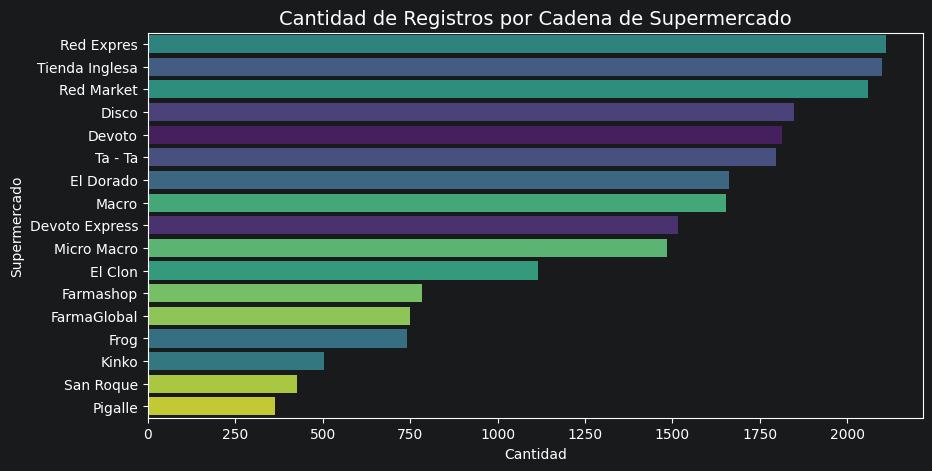

In [142]:
#Frecuencia de la variable categórica (Supermercado) - Gráfico de barras-
plt.figure(figsize=(10, 5))
sns.countplot(data=df_limpio, y='Super',  hue='Super', order=df_limpio['Super'].value_counts().index, palette='viridis', legend=False)
plt.title('Cantidad de Registros por Cadena de Supermercado', fontsize=14)
plt.xlabel('Cantidad')
plt.ylabel('Supermercado')
plt.show()

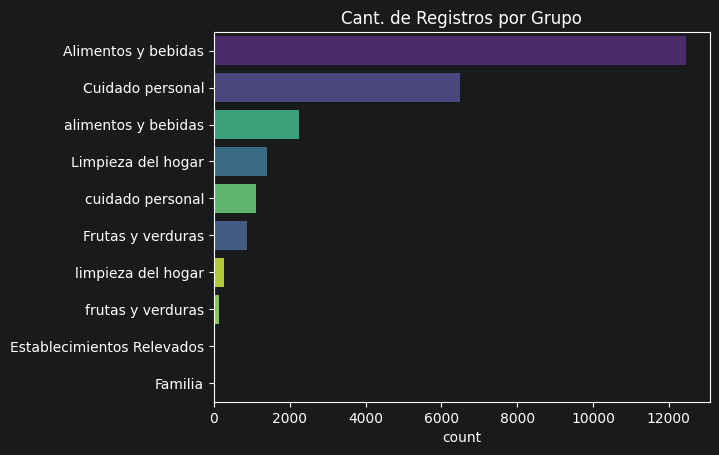

In [143]:
sns.countplot( data=df_limpio,   y="Grupo",  order=df_limpio['Grupo'].value_counts().index,  hue="Grupo",  legend=False, palette="viridis").set(title="Cant. de Registros por Grupo", ylabel=None)
plt.show()

Con estas gráficas noto que debemos realizar además, una limpieza de espacios y estandarización de texto

In [144]:
df_limpio['Grupo'] = df_limpio['Grupo'].str.strip().str.capitalize()
df_limpio['Producto'] = df_limpio['Producto'].str.strip().str.lower()
df_limpio['Super'] = df_limpio['Super'].str.strip().str.title()

In [145]:
df_limpio["Grupo"].value_counts()
df_limpio[df_limpio["Grupo"] == "Familia"].shape
df_limpio[df_limpio["Grupo"] == "Establecimientos relevados"].shape

(22, 5)

In [173]:
# Elimino las filas que contienen Familia y Establecimientos relevados dentro de la columna Grupo
df_limpio = df_limpio[~df_limpio["Grupo"].isin(["Familia", "Establecimientos relevados"])].reset_index(drop=True)

In [174]:
df_limpio["Grupo"].value_counts()

Grupo
Alimentos y bebidas    12270
Cuidado personal        4936
Limpieza del hogar      1438
Frutas y verduras        885
Name: count, dtype: int64

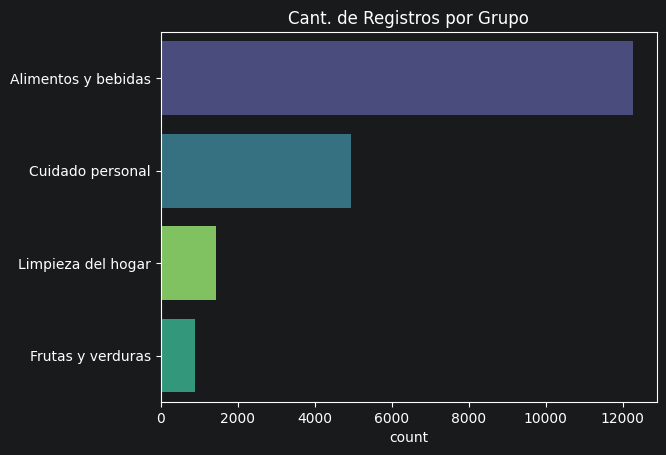

In [175]:
# Rehacemos el gráfico
sns.countplot( data=df_limpio,   y="Grupo",  order=df_limpio['Grupo'].value_counts().index,  hue="Grupo",  legend=False, palette="viridis").set(title="Cant. de Registros por Grupo", ylabel=None)
plt.show()

In [176]:
# Creamos una tabla dinámica
tabla_dinamica = df_limpio.pivot_table(
    values='Precio',
    index='Grupo',
    columns='Super',
    aggfunc='mean',
    observed=False  )

In [177]:
tabla_dinamica

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,Farmaglobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa
Grupo,,,,,,,,,,,,,,,,,
Alimentos y bebidas,149.599331,153.469001,147.610287,127.921965,116.695515,191.689655,128.525714,137.987985,149.606383,155.992993,164.053709,NaN,125.392546,136.092850,269.000000,140.618157,148.071956
Cuidado personal,226.744514,223.971264,226.515674,196.364621,202.290291,194.533425,194.077966,170.403509,143.142857,211.393704,205.256931,230.763393,185.641649,195.125682,223.995798,216.904844,203.673581
Frutas y verduras,103.193878,102.804878,103.061224,NaN,NaN,NaN,NaN,NaN,NaN,100.578485,101.381136,NaN,NaN,78.936441,NaN,101.596907,119.382812
Limpieza del hogar,107.944444,110.800000,107.560185,123.375000,100.965846,127.239515,103.208333,66.770833,102.238095,123.532667,129.046250,NaN,107.827586,99.204745,169.400000,109.859504,106.095833


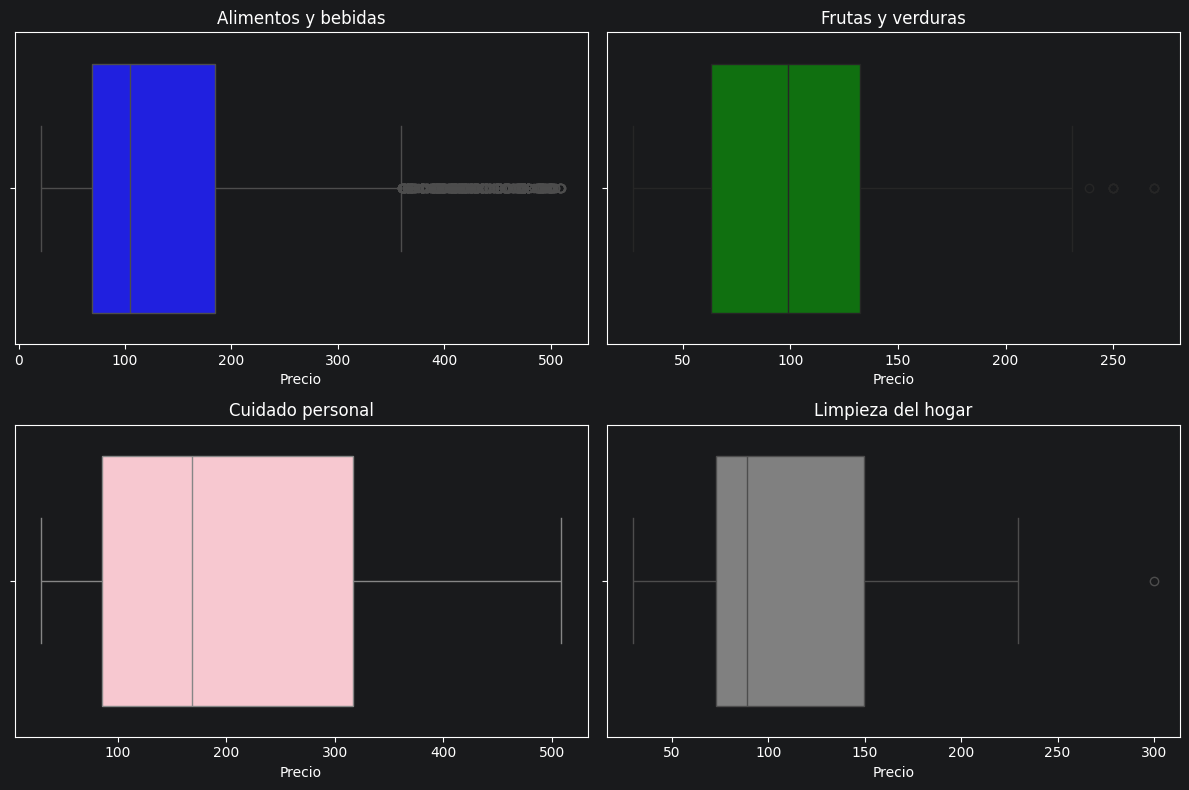

In [178]:
# Matriz de diagramas de caja para el analisis
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
sns.boxplot(ax=axes[0, 0], data=df_limpio[df_limpio['Grupo'] == 'Alimentos y bebidas'], x="Precio", color="blue")
axes[0, 0].set_title("Alimentos y bebidas")
sns.boxplot(ax=axes[0, 1], data=df_limpio[df_limpio['Grupo'] == 'Frutas y verduras'], x="Precio", color="green")
axes[0, 1].set_title("Frutas y verduras")
sns.boxplot(ax=axes[1, 0], data=df_limpio[df_limpio['Grupo'] == 'Cuidado personal'], x="Precio", color="pink")
axes[1, 0].set_title("Cuidado personal")
sns.boxplot(ax=axes[1, 1], data=df_limpio[df_limpio['Grupo'] == 'Limpieza del hogar'], x="Precio", color="gray")
axes[1, 1].set_title("Limpieza del hogar")
plt.tight_layout()
plt.show()


#### _Conclusiones y observaciones del analisis univariante:_

1- El gráfico de barras nos permite visualizar rápidamente el volumen de registros. Notamos en el grafico de establecimientos comerciales que, Pigalle es el establecimiento que tiene menor representatividad en la muestra, o menor variedad de productos, y en el otro extremo tenemos a Red Expres.
2- El grupo alimentos y bebidas es el que domina la muestra, seguido de cuidado personal.
3- Los diagramas de caja muestran que todos los grupos presentan asimetria a la derecha, esto se puede deber a que dentro de las listas de precios de cada grupo, podemos encontrarnos con algunos productos premium que funcionen como outliers ya que sus precios son más altos.
4- La tabla dinamica es útil ya que nos permitió resumir grandes volumenes de datos, y podemos extraer precios promedio, y aplicar sumas o conteos.

## 5.2 Análisis multivariante

Ahora se buscara cruzar datos para obtener información de la relación existente entre las variables para ya acercarnos a sacar conlsuiones que nos permitan abordar nuestro objetivo principal del proyecto: ofrecer información a los consumidores que permita entender el comportamiento del mercado comercial, la competitividad entre las cadenas y el comportamiento de los costos de productos y grupos de productos a lo largo del tiempo estudiado.
En este caso, el análisis multivariante se enfocará principalmente en comparar la única variable numérica Precio con variables categóricas como Grupo, Super, Producto y Periodo. Por eso realizaremos un análisis categorico- categórico y uno numérico-categórico.


#### 5.2.2 Análisis categórico - categórico:

Cuando ambas variables contienen texto (categorías), utilizamos gráficos de conteo combinados para ver cómo se distribuyen los datos. En este caso, cruzaremos la variable Super con el Grupo para entender la composición del catálogo de cada cadena comercial.

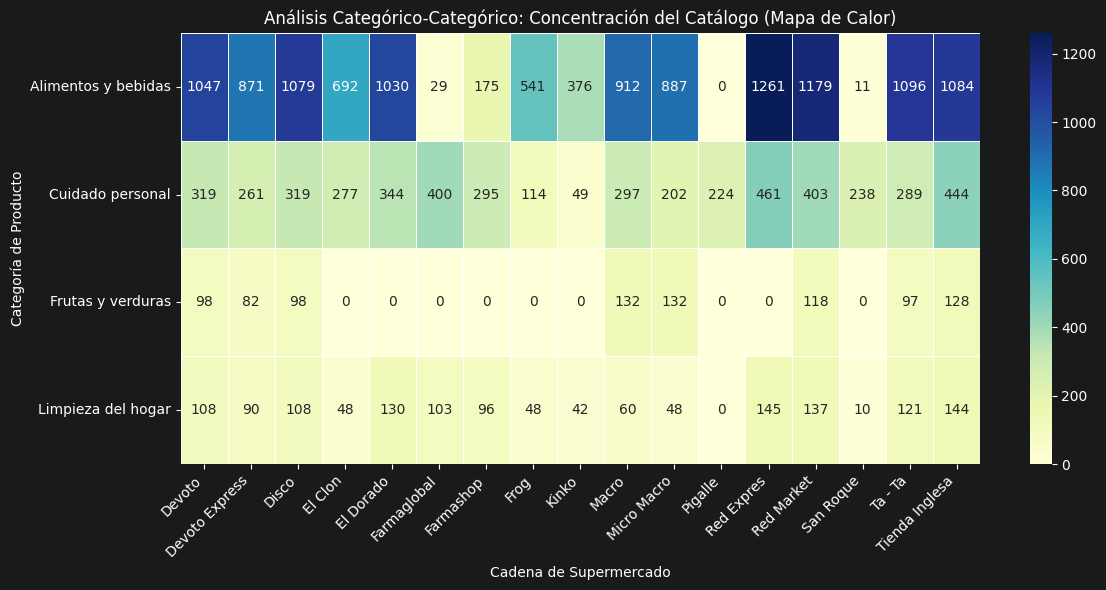

In [179]:
# 1. Creamos una Crosstab que cuente cuántas veces se cruza cada Grupo con cada Supermercado
tabla_contingencia = pd.crosstab(df_limpio['Grupo'], df_limpio['Super'])

# 2. Dibujamos el mapa basado en esa tabla
plt.figure(figsize=(12, 6))
sns.heatmap(tabla_contingencia, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title("Análisis Categórico-Categórico: Concentración del Catálogo (Mapa de Calor)")
plt.xlabel("Cadena de Supermercado")
plt.ylabel("Categoría de Producto")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Observaciones :

Las celdas con colores más oscuros y números más altos indican dónde está la mayor concentración de oferta.
* La categoría que domina ampliamente en todos los supermercados es la de **alimentos y bebidas** (es el color más oscuro), confirmando que el mercado se centra en bienes de primera necesidad.
* Ningún supermercado destaca por tener una oferta radicalmente distinta a los demás (los patrones de colores son casi iguales en todas las cadenas). Esto demuestra que compiten directamente por precio, y no por ofrecer productos exclusivos.
* Categorías como **cuidado personal** tienen muy poca representación. Esto nos advierte que nuestro futuro modelo cuando aprendamos machine learning, será mucho más preciso prediciendo precios de alimentos que de artículos de nicho, ya que tendrá más datos para aprender.



#### 5.2.3 Análisis numérico - categórico:

Como vimos en clase, este es el análisis a mayor detalle que podemos llevar a cabo.Cruzaremos nuestra variable numerica principal que es Precio con nuestras variables categoricas Grupo y Super para analizar por ejemplo, qué supermercado es mas conveniente para ahorrar. Tambien usaremos la variable período para ver la evolución temporal.

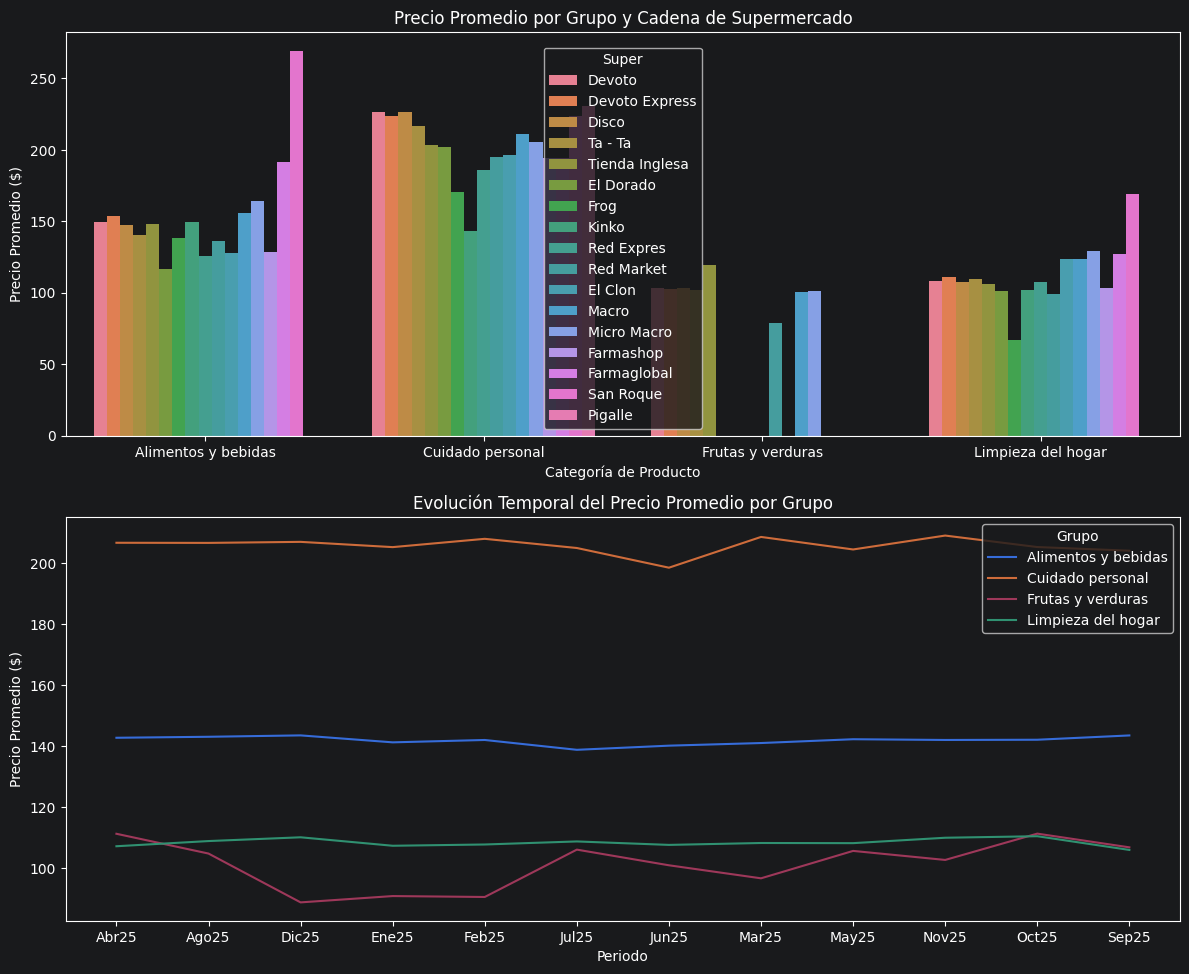

In [180]:
# Creamos una figura con dos gráficos para comparar variables
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# 1. Gráfico de barras: Cruzamos Precio vs Grupo vs Supermercado
sns.barplot(ax=axes[0], data=df_limpio, x='Grupo', y='Precio', hue='Super', errorbar=None)
axes[0].set_title("Precio Promedio por Grupo y Cadena de Supermercado")
axes[0].set_xlabel("Categoría de Producto")
axes[0].set_ylabel("Precio Promedio ($)")

# 2. Gráfico de líneas: Cruzamos Precio vs Periodo vs Grupo
sns.lineplot(ax=axes[1], data=df_limpio, x='Periodo', y='Precio', hue='Grupo', errorbar=None)
axes[1].set_title("Evolución Temporal del Precio Promedio por Grupo")
axes[1].set_xlabel("Periodo")
axes[1].set_ylabel("Precio Promedio ($)")

plt.tight_layout()
plt.show()


#### **Conclusiones y observaciones del análisis multivariante:**

En esta sección cruzamos nuestras variables : precio (en promedio), con grupo y con cadenas de supermercados, y entendimos dos aspectos claves de la dinamica comercial de uruguay:

1. **Competitividad:** El gráfico de barras demuestra que no existe una única cadena que sea "la más cara" o "la más barata" en términos absolutos. La conveniencia de compra depende fuertemente de la categoría (Grupo) que se analice.
2. **Tendencia Temporal:** El gráfico de líneas nos permite estudiar la trayectoria de los costos. Podemos identificar si ciertas categorías sufren picos inflacionarios o variaciones estacionales en determinados periodos del año. Por ejemplo, el grupo " cuidado personal" es el que sufre más variaciones a lo largo del periodo analizado; mientras que alimenos y bebidas sigue un comportamiento mas estable a lo largo del tiempo.

# PASO 6: Ingeniería de características

Proceso que implica la creación de nuevas características a partir de las existentes para mejorar el rendimiento del modelo, implicando de técnicas como la normalización, la transformación de los datos, etc. El objetivo es mejorar la precisión del modelo y/o reducir la complejidad del mismo, facilitando así su interpretación.

## 6.1 Análisis de Outliers

Un outlier es una observación dentro de un conjunto de datos que difiere drásticamente del comportamiento general de la muestra. Estos valores extremos sobresalen numéricamente del resto de los puntos y pueden alterar significativamente los resultados estadísticos de nuestro proyecto, por lo que hay que decidir cómo tratarlos, si removerlos de la muestra, reemplazarlos o mantenerlos; una forma útil y visual de identificarlos es mediante diagramas de caja o boxplot.

In [181]:
df_limpio.describe().T

,count,mean,std,min,25%,50%,75%,max
Precio,19529.0,153.717958,112.91668,21.0,72.0,116.0,194.22,510.0


El precio promedio de todos los productos de nuestro DF es de 129 pesos, el primer cuartil (25% inferior) es de 75 pesos y el 3er cuartil (75%) es de 250,5 pesos; por lo tanto, un precio como el precio máximo de 25800 nos distorciona completamente los valores de la muestra y puede hacer que saquemos conclusiones equivocadas.

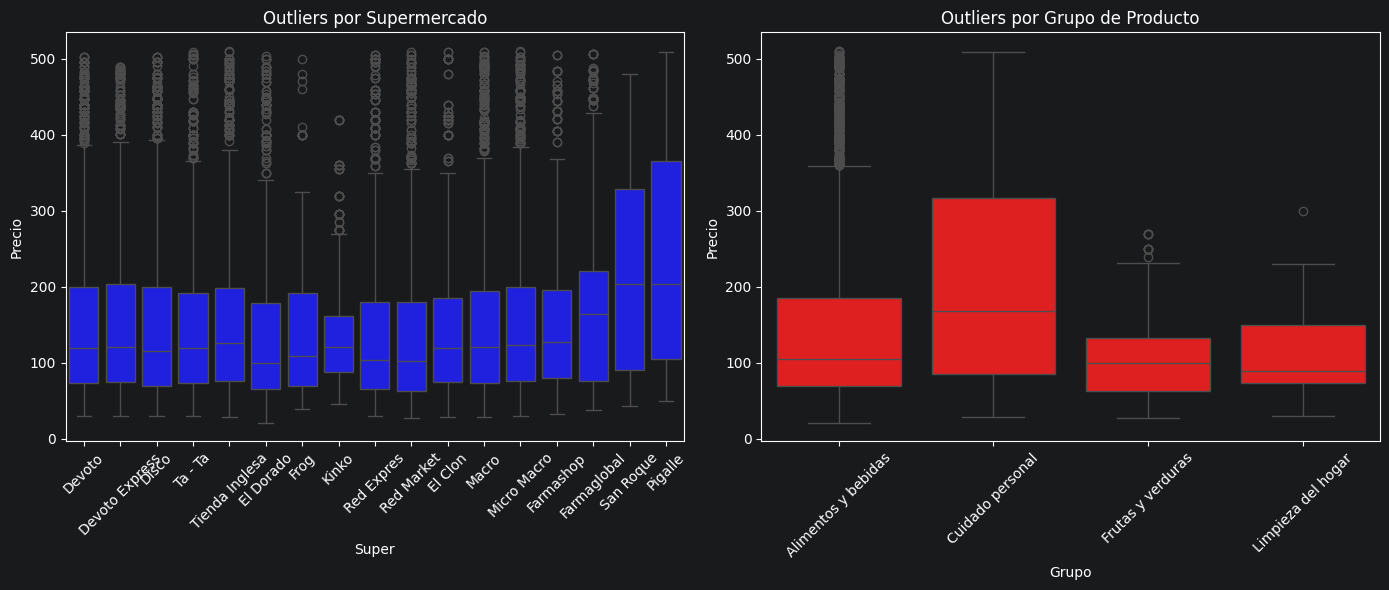

In [183]:
# visualizamos con boxplots
fig, axis = plt.subplots(1, 2, figsize=(14, 6))

# 1. Boxplot de precios por supermercado
sns.boxplot(ax=axis[0], data=df_limpio, x="Super", y="Precio", color="blue")
axis[0].set_title("Outliers por Supermercado")
axis[0].tick_params(axis='x', rotation=45)

# 2. Boxplot de precios separados por Grupo de Producto
sns.boxplot(ax=axis[1], data=df_limpio, x="Grupo", y="Precio", color="red")
axis[1].set_title("Outliers por Grupo de Producto")
axis[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [184]:
#Analizamos a que productos refieren esos puntos de los diagramas de caja que se alejan considerablemente de las restantes observaciones de la muestra:
print("\nTOP 10 PRECIOS MÁS ALTOS EN LA TABLA ORIGINAL:")
display(df_limpio.sort_values("Precio", ascending=False).head(10))


TOP 10 PRECIOS MÁS ALTOS EN LA TABLA ORIGINAL:


,Periodo,Grupo,Producto,Super,Precio,Rango_Precio
19488,Nov25,Alimentos y bebidas,margarina adorita envase 250 grs.,Tienda Inglesa,510.00,Premium
12056,Mar25,Alimentos y bebidas,peceto vacuno sin marca 1 kg.,Micro Macro,509.99,Premium
15936,Nov25,Cuidado personal,"repelente spray off! family, 177 cm3",El Clon,509.00,Premium
1381,Abr25,Cuidado personal,"repelente spray off! family, 177 cm3",Pigalle,509.00,Premium
6062,Ene25,Cuidado personal,"champú dove, 400 ml.",Ta - Ta,509.00,Premium
10980,Jun25,Cuidado personal,shampoo comun pantene (400 ml.),Tienda Inglesa,509.00,Premium
5784,Ene25,Alimentos y bebidas,peceto vacuno sin marca 1 kg.,Micro Macro,509.00,Premium
5783,Ene25,Alimentos y bebidas,peceto vacuno sin marca 1 kg.,Macro,509.00,Premium
7457,Feb25,Alimentos y bebidas,peceto vacuno sin marca 1 kg.,Macro,509.00,Premium
4686,Dic25,Cuidado personal,"repelente spray off! family, 177 cm3",El Clon,509.00,Premium


#### _Observaciones:_

La variable numerica precio es la que se ve afectada por valores atipicos, como por ejemplo el valor de la muestra de protector solor eucerin que se vende en Tienda Inglesa por 25800 pesos. Este registro influye y se puede tratar incluso, de un error de medida o de recoleccion de la información; por lo que procederemos eliminando los outliers del análisis, aunque dejaremos una copia del df con ellos por si queremos revisarlos.

In [185]:
# Cálculo de cuartiles para definir el limite superior
Q1 = df_limpio["Precio"].quantile(0.25)
Q3 = df_limpio["Precio"].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

In [186]:
# Guardo una copia de los outliers:
df_outliers_guardados = df_limpio[df_limpio["Precio"] > limite_superior].copy()

In [187]:
# Nos quedamos estrictamente con los precios que sean MENORES O IGUALES al límite superior
df_limpio = df_limpio[df_limpio["Precio"] <= limite_superior].reset_index(drop=True)

In [188]:
# Nos quedamos estrictamente con los precios que sean MENORES O IGUALES al límite
df_limpio = df_limpio[df_limpio["Precio"] <= limite_superior].reset_index(drop=True)

In [189]:
# Verificación:
print("Cantidad de outliers extraídos y guardados:", df_outliers_guardados.shape[0])
print("Nuevo tamaño del dataset listo para el modelo:", df_limpio.shape)
print("-" * 50)

Cantidad de outliers extraídos y guardados: 1466
Nuevo tamaño del dataset listo para el modelo: (18063, 6)
--------------------------------------------------


In [190]:
display(df_limpio.head())

,Periodo,Grupo,Producto,Super,Precio,Rango_Precio
0,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto,80.0,Económico
1,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto Express,99.0,Estándar
2,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Disco,99.0,Estándar
3,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Ta - Ta,95.0,Estándar
4,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Tienda Inglesa,97.0,Estándar


## 6.2 Análisis de valores faltantes

Un valor faltante es un espacio que no tiene valor asignado en la observación y se puede identificar con la función isnull()

In [191]:
df_limpio.shape[0]

18063

In [192]:
df_limpio.isnull().sum()

Periodo         0
Grupo           0
Producto        0
Super           0
Precio          0
Rango_Precio    0
dtype: int64

In [193]:
filas_con_nulos = df_limpio.isnull().any(axis=1).sum()
print(f"Filas totales afectadas por nulos: {filas_con_nulos}")

Filas totales afectadas por nulos: 0


In [194]:
df_limpio.columns.tolist()

['Periodo', 'Grupo', 'Producto', 'Super', 'Precio', 'Rango_Precio']

In [195]:
# Borramos filas donde falte información
df_limpio = df_limpio.dropna(subset=["Grupo", "Super", "Precio"]).reset_index(drop=True)

In [196]:
nulos_restantes = df_limpio.isnull().any(axis=1).sum()
print(f"\nFilas con nulos restantes: {nulos_restantes}")


Filas con nulos restantes: 0


#### _Conclusiones:_

Se decidió por eliminar los valores nulos de nuestras columnas, utilizando dropna(), haciendo uso unicamente de la ifnormación con todas las columnas completas.

## 6.3 Inferencia en nuevas características

Esta sección tiene el objetivo de obtener nuevas características con las ya existentes con el objetivo de simplificar el número de variables y trazar nuevas relaciones.

In [197]:
# 2. Variable Rango de Precio
df_limpio['Rango_Precio'] = pd.qcut(df_limpio['Precio'], q=3, labels=['Económico', 'Estándar', 'Premium'])

In [198]:
# Verificamos
display(df_limpio[['Super', 'Grupo', 'Precio', 'Rango_Precio']].sample(5))

,Super,Grupo,Precio,Rango_Precio
16008,Red Expres,Alimentos y bebidas,98.0,Estándar
4395,Devoto,Frutas y verduras,69.0,Económico
3711,Red Market,Alimentos y bebidas,96.0,Estándar
8629,Red Expres,Cuidado personal,169.0,Premium
1973,Ta - Ta,Alimentos y bebidas,211.0,Premium


In [199]:
# Definimos el orden lógico para que se lea de menor a mayor valor
orden_rangos = ['Económico', 'Estándar', 'Premium']

In [206]:
# Creamos variable mes
mapa_meses = {
    "Ene25": 1,
    "Feb25": 2,
    "Mar25": 3,
    "Abr25": 4,
    "May25": 5,
    "Jun25": 6,
    "Jul25": 7,
    "Ago25": 8,
    "Sep25": 9,
    "Oct25": 10,
    "Nov25": 11,
    "Dic25": 12
}

df_limpio["Mes"] = df_limpio["Periodo"].map(mapa_meses)

In [207]:
df_limpio["Periodo"].unique()
df_limpio["Mes"].isnull().sum()

np.int64(0)

In [210]:
#Creamos trimestres desde la variable mes
def asignar_trimestre(mes):
    if mes in [1, 2, 3]: return 'Q1 (Ene-Mar)'
    elif mes in [4, 5, 6]: return 'Q2 (Abr-Jun)'
    elif mes in [7, 8, 9]: return 'Q3 (Jul-Sep)'
    elif mes in [10, 11, 12]: return 'Q4 (Oct-Dic)'
    else: return 'Desconocido'

In [211]:
df_limpio['Trimestre'] = df_limpio['Mes'].apply(asignar_trimestre)

In [214]:
df_limpio

,Periodo,Grupo,Producto,Super,Precio,Rango_Precio,Mes,Trimestre
0,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto,80.0,Estándar,4,Q2 (Abr-Jun)
1,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Devoto Express,99.0,Estándar,4,Q2 (Abr-Jun)
2,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Disco,99.0,Estándar,4,Q2 (Abr-Jun)
3,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Ta - Ta,95.0,Estándar,4,Q2 (Abr-Jun)
4,Abr25,Alimentos y bebidas,aceite de girasol marca propia envase 900 cc,Tienda Inglesa,97.0,Estándar,4,Q2 (Abr-Jun)
...,...,...,...,...,...,...,...,...
18058,Oct25,Limpieza del hogar,jabón para ropa en barra primor unidad 300 grs.,Red Expres,300.0,Premium,10,Q4 (Oct-Dic)
18059,Ene25,Alimentos y bebidas,hamburguesas carne vacun burgy paquete 3 unidades,Devoto Express,350.0,Premium,1,Q1 (Ene-Mar)
18060,Abr25,Alimentos y bebidas,arvejas en conserva nidemar lata 300 grs.,Micro Macro,326.6,Premium,4,Q2 (Abr-Jun)
18061,Jun25,Alimentos y bebidas,margarina con sal adorita (envase 250 grs.),Disco,300.0,Premium,6,Q2 (Abr-Jun)


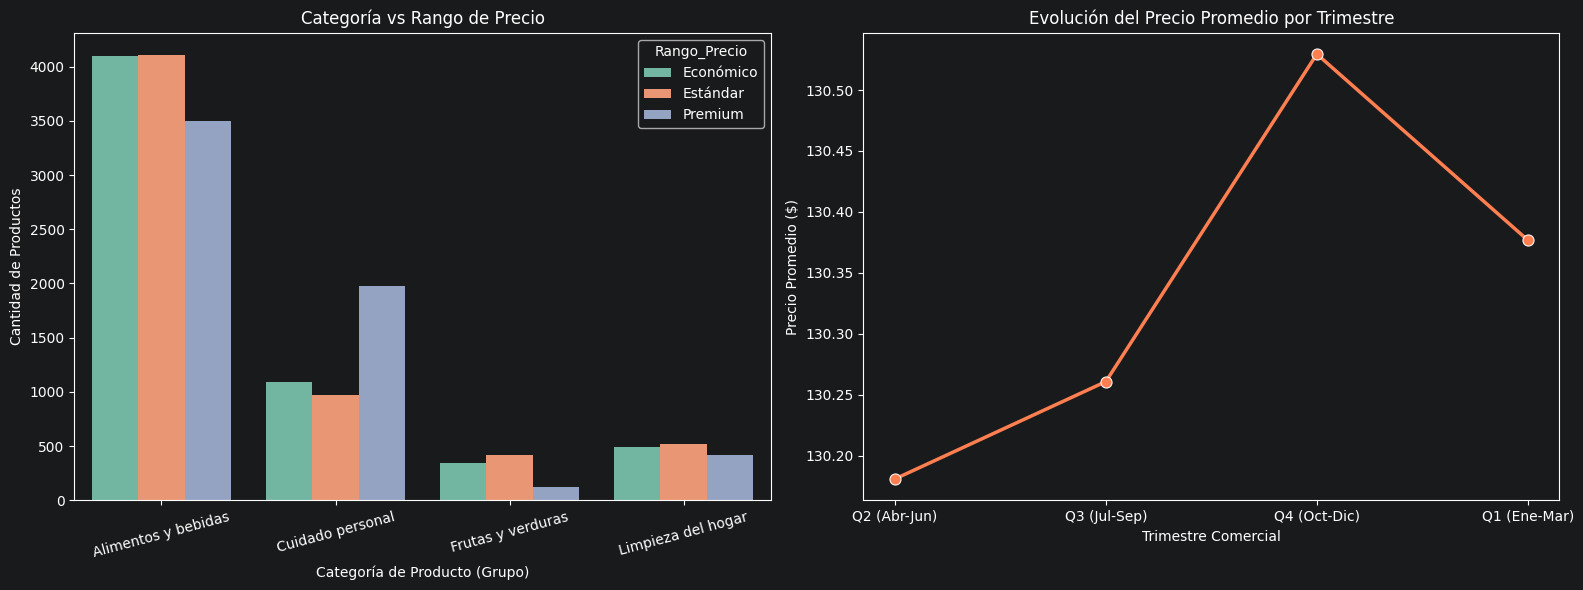

In [217]:
# Grafiquemos las nuevas características para visualizar nueva información
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=df_limpio,
    x='Grupo',
    hue='Rango_Precio',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Categoría vs Rango de Precio')
axes[0].set_xlabel('Categoría de Producto (Grupo)')
axes[0].set_ylabel('Cantidad de Productos')
axes[0].tick_params(axis='x', rotation=15)

sns.lineplot(
    data=df_limpio,
    x='Trimestre',
    y='Precio',
    estimator='mean',
    errorbar=None,
    ax=axes[1],
    marker='o',
    markersize=8,
    color='coral',
    linewidth=2.5
)
axes[1].set_title('Evolución del Precio Promedio por Trimestre')
axes[1].set_xlabel('Trimestre Comercial')
axes[1].set_ylabel('Precio Promedio ($)')

plt.tight_layout()
plt.show()

#### _Observaciones y conclusiones:_

La ingenieria de nuevas caracteristicas me permite analizar nuevos aspectos de mis observaciones, por ejemplo, al haber creado la nueva variable " Rango de precio" ahora es posible analizar comportamientos entre los grupos de productos (o categorias ) y sacar cocnlsuiones como que, la categoría " cuidado personal" tiene un comportamiento algo diferente a las los demas grupos, la misma cuenta con mayor cantidad de productos Premium (esto tiene sentido dado que, en la seccion qeu exploramos la data, notabamos que productos como los protectores solares clasificados dentro de cuidado eprsonal, eran aquellos que tenian mayores precios).

Mientras tanto, en las categorias de productos asociados a " alimentos y bebidas" y " frutas y verduras" predominan los rangos de precios económico y estandar, lo que es congruente con la logica de oferta de commodities y el comportamiento que tienen estos bienes de consumo masivo.

Otra conclusion que podemos deducir de estos graficos es que, notamos una estacionalidad en los trimestres 1, 2 y 3, pero el último (Q4) tiene una tendencia alcista en el precio promedio, que podría explicarse por ser una estación del año altamente influenciada por aumento de demanda en el sector de retail debido a las fiestas; aunque para asegurarnos de que esta sea la razon, se podría extender el análisis a analizar la fluctuación historica comparando el Q4 de años anteriores.(esto excede el análisis actual).
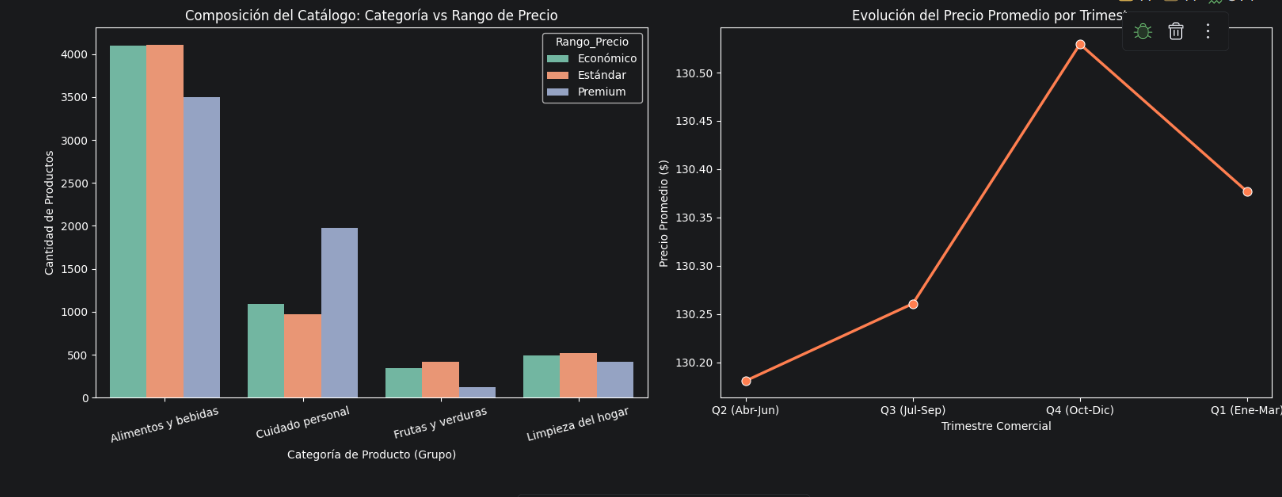

## Paso 7: Split (dos métodos o enfoques)